In [55]:
import numpy as np
from array import array
from IPython.display import Image, display


In [3]:
n = 12
theta_array = np.arange(0, 2 * np.pi, 2 * np.pi / n, dtype=np.float32)
shape_array = []

for theta in theta_array:
    shape_array.append(np.cos(theta))
    shape_array.append(np.sin(theta))

shape_array = np.array(shape_array, dtype=np.float32)


In [ ]:
with open('data/vertex_data.dat', 'wb') as f:
    array('f', shape_array).tofile(f)


In [7]:
with open('data/vertex_data.dat', 'rb') as f:
    shape_array = array('f')
    shape_array.frombytes(f.read())
    print(shape_array)

array('f', [1.0, 0.0, 0.8660253882408142, 0.5, 0.4999999701976776, 0.866025447845459, -4.371138828673793e-08, 1.0, -0.5000000596046448, 0.8660253882408142, -0.8660253882408142, 0.5000000596046448, -1.0, -8.742277657347586e-08, -0.8660253286361694, -0.5000001788139343, -0.49999991059303284, -0.866025447845459, 1.1924880638503055e-08, -1.0, 0.49999991059303284, -0.866025447845459, 0.8660255670547485, -0.4999997615814209])


In [8]:
theta_array

array([0.       , 0.5235988, 1.0471976, 1.5707964, 2.0943952, 2.6179938,
       3.1415927, 3.6651917, 4.1887903, 4.712389 , 5.2359877, 5.759587 ],
      dtype=float32)

In [11]:
import cv2


In [56]:
def imshow(img):
    """ndarray 配列をインラインで Notebook 上に表示する。"""
    ret, encoded = cv2.imencode(".png", img)
    display(Image(encoded))

In [149]:
img = cv2.imread('data/reimu.png~', cv2.IMREAD_UNCHANGED)
gray = img[:, :, 3]
ret, alpha = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)


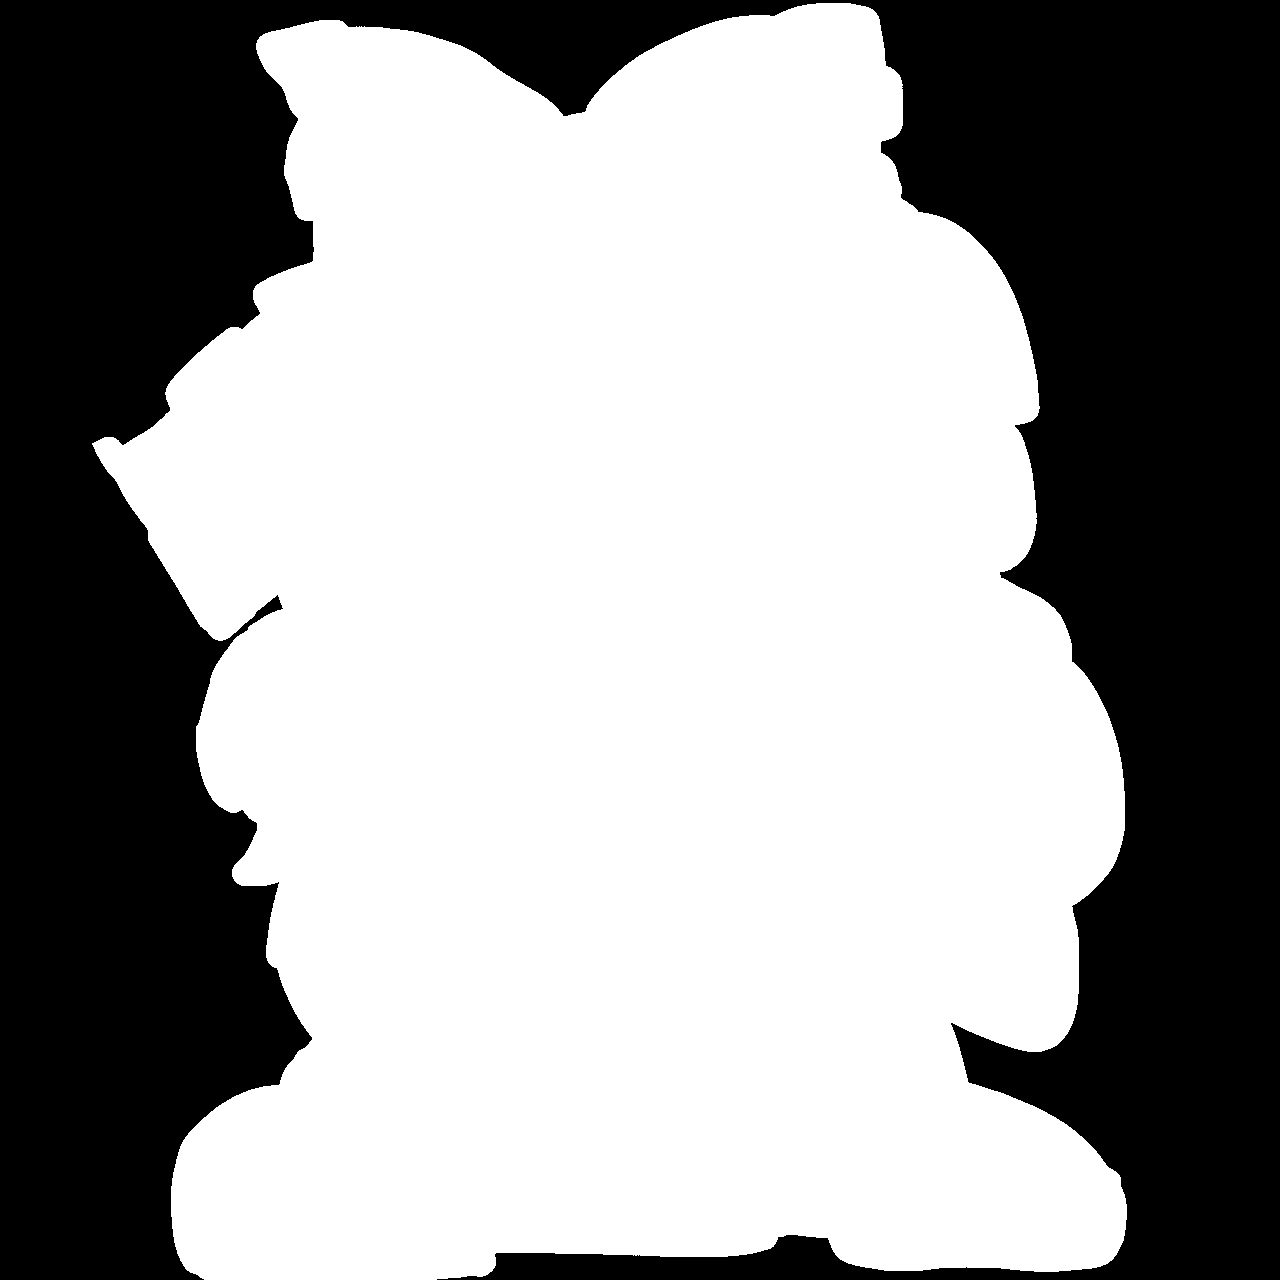

In [150]:
mask = np.zeros((alpha.shape[0] + 2, alpha.shape[1] + 2), dtype=alpha.dtype)
_, binary, _, _ = cv2.floodFill(alpha, mask, (0, 0), 100)
binary = (binary != 100).astype(np.uint8) * 255

imshow(binary)


In [151]:
np.unique(binary)

array([  0, 255], dtype=uint8)

In [156]:
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_KCOS)
contours = contours[0][:, 0, :].astype(np.float32)


In [157]:
contours.shape

(683, 2)

In [158]:
contours[:, 0] -= alpha.shape[0] / 2
contours[:, 1] -= alpha.shape[1] / 2

contours[:, 0] /= alpha.shape[0] / 2
contours[:, 1] /= -alpha.shape[1] / 2


In [159]:
with open('data/vertex_data.dat', 'wb') as f:
    array('f', contours.flatten()).tofile(f)
